In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
# Definir el tamaño de la cuadrícula
grid_size = 50  # Tamaño de la cuadrícula (por ejemplo, 50x50)

# Inicializamos la cuadrícula con ceros
potential_circle = np.zeros((grid_size, grid_size))

# Condiciones de frontera (cuadrado exterior a φ = 0)
potential_circle[:, 0] = 0  # Borde izquierdo
potential_circle[:, -1] = 0  # Borde derecho
potential_circle[0, :] = 0  # Borde superior
potential_circle[-1, :] = 0  # Borde inferior

# Definir un círculo interno con φ(θ) = sin²(θ)
radius = 10  # Radio del círculo interno
center = grid_size // 2  # Centro del círculo en la cuadrícula

# Aplicamos las condiciones de frontera en el círculo interno
for i in range(grid_size):
    for j in range(grid_size):
        dist = np.sqrt((i - center)**2 + (j - center)**2)
        if dist <= radius:
            theta = np.arctan2(j - center, i - center)
            potential_circle[i, j] = np.sin(theta)**2  # φ(θ) = sin²(θ)

# Función de relajación para el círculo
def relaxation_step_circle(potential, tolerance=1e-6):
    max_diff = tolerance + 1
    while max_diff > tolerance:
        new_potential = potential.copy()
        max_diff = 0
        
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                dist = np.sqrt((i - center)**2 + (j - center)**2)
                if dist > radius:  # Saltar la región del círculo
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential
        print(f"Máxima diferencia en esta iteración (círculo): {max_diff}")
    
    return potential

# Graficar el potencial para el círculo
def plot_potential_circle(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (círculo interno)")
    plt.show()

# Ejecutamos el método de relajación para el círculo y graficamos
relaxed_potential_circle = relaxation_step_circle(potential_circle)
plot_potential_circle(relaxed_potential_circle)

# Calcular el campo eléctrico para el círculo y graficarlo
Ex_circle, Ey_circle = np.gradient(-relaxed_potential_circle)

def plot_electric_field_circle(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Círculo interno)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_circle(Ex_circle, Ey_circle)


NameError: name 'np' is not defined

Máxima diferencia en esta iteración (cuadrado): 25.0
Máxima diferencia en esta iteración (cuadrado): 12.5
Máxima diferencia en esta iteración (cuadrado): 7.8125
Máxima diferencia en esta iteración (cuadrado): 6.25
Máxima diferencia en esta iteración (cuadrado): 4.6875
Máxima diferencia en esta iteración (cuadrado): 4.0283203125
Máxima diferencia en esta iteración (cuadrado): 3.485107421875
Máxima diferencia en esta iteración (cuadrado): 3.0426025390625
Máxima diferencia en esta iteración (cuadrado): 2.6821136474609375
Máxima diferencia en esta iteración (cuadrado): 2.3754119873046875
Máxima diferencia en esta iteración (cuadrado): 2.1311283111572266
Máxima diferencia en esta iteración (cuadrado): 1.9142627716064453
Máxima diferencia en esta iteración (cuadrado): 1.7804324626922607
Máxima diferencia en esta iteración (cuadrado): 1.6696985810995102
Máxima diferencia en esta iteración (cuadrado): 1.5524650923907757
Máxima diferencia en esta iteración (cuadrado): 1.4637477463111281
Máxima 

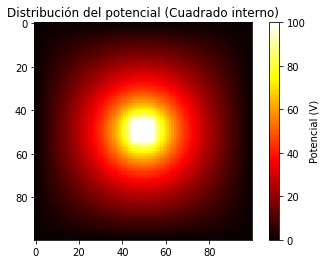

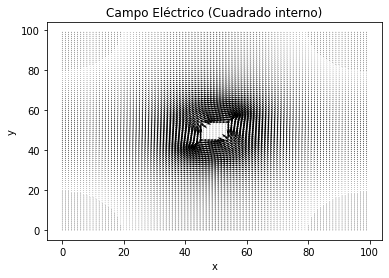

Máxima diferencia en esta iteración (círculo): 0.4969512195121951
Máxima diferencia en esta iteración (círculo): 0.18673780487804878
Máxima diferencia en esta iteración (círculo): 0.1089939024390244
Máxima diferencia en esta iteración (círculo): 0.0922446646341463
Máxima diferencia en esta iteración (círculo): 0.06521532012195125
Máxima diferencia en esta iteración (círculo): 0.05545207698170734
Máxima diferencia en esta iteración (círculo): 0.04342898485137198
Máxima diferencia en esta iteración (círculo): 0.03853268507050306
Máxima diferencia en esta iteración (círculo): 0.03394046318240279
Máxima diferencia en esta iteración (círculo): 0.030514460307795838
Máxima diferencia en esta iteración (círculo): 0.027259464380217785
Máxima diferencia en esta iteración (círculo): 0.024692499637603782
Máxima diferencia en esta iteración (círculo): 0.02236280074206798
Máxima diferencia en esta iteración (círculo): 0.020396841251995534
Máxima diferencia en esta iteración (círculo): 0.018699582003

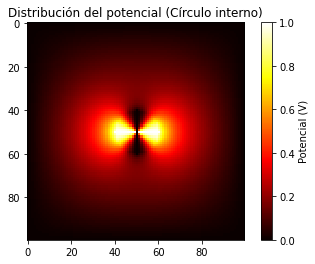

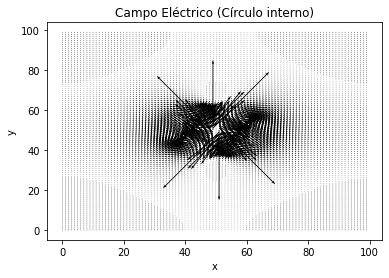

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos el tamaño de la cuadrícula
grid_size = 100  # Tamaño de la cuadrícula

# ---- CASO 1: CUADRADO INTERNO ----

# Inicializamos la cuadrícula con ceros
potential_square = np.zeros((grid_size, grid_size))

# Condiciones de frontera
potential_square[:, 0] = 0  # Borde izquierdo
potential_square[:, -1] = 0  # Borde derecho
potential_square[0, :] = 0  # Borde superior
potential_square[-1, :] = 0  # Borde inferior

# Definir un cuadrado interno con potencial φ=100
internal_square_size = 10  # Tamaño del cuadrado interno
start = (grid_size - internal_square_size) // 2
end = start + internal_square_size

potential_square[start:end, start:end] = 100  # Región interna a φ = 100

# Función de relajación para el cuadrado
def relaxation_step_square(potential, tolerance=1e-6):
    max_diff = tolerance + 1  # Iniciar con una diferencia mayor al criterio
    while max_diff > tolerance:
        new_potential = potential.copy()  # Crear una copia de los valores actuales
        max_diff = 0  # Inicializar la diferencia máxima

        # Actualizar cada punto interno de la cuadrícula
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                if not (start <= i < end and start <= j < end):  # Saltar la región de φ = 100
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential  # Actualizar la cuadrícula con los nuevos valores
        print(f"Máxima diferencia en esta iteración (cuadrado): {max_diff}")
    
    return potential

# Graficar el potencial para el cuadrado
def plot_potential_square(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Cuadrado interno)")
    plt.show()

# Ejecutar el método de relajación para el cuadrado y graficar
relaxed_potential_square = relaxation_step_square(potential_square)
plot_potential_square(relaxed_potential_square)

# Calcular el campo eléctrico para el cuadrado y graficar
Ex_square, Ey_square = np.gradient(-relaxed_potential_square)

def plot_electric_field_square(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Cuadrado interno)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_square(Ex_square, Ey_square)

# ---- CASO 2: CÍRCULO INTERNO ----

# Inicializamos la cuadrícula con ceros
potential_circle = np.zeros((grid_size, grid_size))

# Condiciones de frontera (cuadrado exterior a φ = 0)
potential_circle[:, 0] = 0  # Borde izquierdo
potential_circle[:, -1] = 0  # Borde derecho
potential_circle[0, :] = 0  # Borde superior
potential_circle[-1, :] = 0  # Borde inferior

# Definir un círculo interno con φ(θ) = sin²(θ)
radius = 10  # Radio del círculo interno
center = grid_size // 2  # Centro del círculo en la cuadrícula

# Aplicamos las condiciones de frontera en el círculo interno
for i in range(grid_size):
    for j in range(grid_size):
        dist = np.sqrt((i - center)**2 + (j - center)**2)
        if dist <= radius:
            theta = np.arctan2(j - center, i - center)
            potential_circle[i, j] = np.sin(theta)**2  # φ(θ) = sin²(θ)

# Función de relajación para el círculo
def relaxation_step_circle(potential, tolerance=1e-6):
    max_diff = tolerance + 1
    while max_diff > tolerance:
        new_potential = potential.copy()
        max_diff = 0
        
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                dist = np.sqrt((i - center)**2 + (j - center)**2)
                if dist > radius:  # Saltar la región del círculo
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential
        print(f"Máxima diferencia en esta iteración (círculo): {max_diff}")
    
    return potential

# Graficar el potencial para el círculo
def plot_potential_circle(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Círculo interno)")
    plt.show()

# Ejecutamos el método de relajación para el círculo y graficamos
relaxed_potential_circle = relaxation_step_circle(potential_circle)
plot_potential_circle(relaxed_potential_circle)

# Calcular el campo eléctrico para el círculo y graficarlo
Ex_circle, Ey_circle = np.gradient(-relaxed_potential_circle)

def plot_electric_field_circle(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Círculo interno)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_circle(Ex_circle, Ey_circle)


Máxima diferencia en esta iteración: 25.0
Máxima diferencia en esta iteración: 12.5
Máxima diferencia en esta iteración: 7.8125
Máxima diferencia en esta iteración: 5.46875
Máxima diferencia en esta iteración: 4.6875
Máxima diferencia en esta iteración: 4.0283203125
Máxima diferencia en esta iteración: 3.4912109375
Máxima diferencia en esta iteración: 3.0548095703125
Máxima diferencia en esta iteración: 2.69775390625
Máxima diferencia en esta iteración: 2.4026870727539062
Máxima diferencia en esta iteración: 2.1560192108154297
Máxima diferencia en esta iteración: 1.9481360912322998
Máxima diferencia en esta iteración: 1.8262669444084167
Máxima diferencia en esta iteración: 1.7129983752965927
Máxima diferencia en esta iteración: 1.6098838299512863
Máxima diferencia en esta iteración: 1.513678824994713
Máxima diferencia en esta iteración: 1.427066745236516
Máxima diferencia en esta iteración: 1.3453946099616587
Máxima diferencia en esta iteración: 1.2725002037768718
Máxima diferencia en 

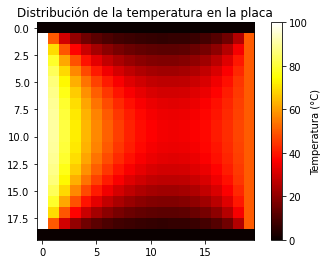

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Definir el tamaño de la cuadrícula
grid_size = 20  
tolerance = 1e-4  

# Inicializar la cuadrícula de temperatura
temperature = np.zeros((grid_size, grid_size))

# Condiciones de frontera
temperature[:, 0] = 100  # Borde izquierdo a 100 grados
temperature[:, -1] = 50  # Borde derecho a 50 grados
temperature[0, :] = 0  # Borde superior a 0 grados
temperature[-1, :] = 0  # Borde inferior a 0 grados

# Función de relajación
def relaxation_step(temperature, tolerance):
    max_diff = tolerance + 1  # Inicializamos con una diferencia mayor a la tolerancia
    while max_diff > tolerance: #Ciclo que continuara hasta que se cumpla la tolerancia
        new_temperature = temperature.copy()  # Crear una copia de los valores actuales
        max_diff = 0  # Inicializar la diferencia máxima

        # Actualizar cada punto interno de la cuadrícula
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                # Actualizar el valor de la temperatura en el punto (i, j)
                new_value = 0.25 * (temperature[i+1, j] + temperature[i-1, j] +
                                    temperature[i, j+1] + temperature[i, j-1])
                max_diff = max(max_diff, abs(new_value - temperature[i, j]))
                new_temperature[i, j] = new_value
                #Podemos notar que acá se obtiene el promedio de los lados de la cuadricula.

        temperature = new_temperature  # Actualizar la cuadrícula con los nuevos valores
        print(f"Máxima diferencia en esta iteración: {max_diff}")
    
    return temperature

# Ejecutar el método de relajación y obtener la solución
final_temperature = relaxation_step(temperature, tolerance)

# Graficar la distribución de la temperatura
plt.imshow(final_temperature, cmap='hot', interpolation='nearest')
plt.colorbar(label="Temperatura (°C)")
plt.title("Distribución de la temperatura en la placa")
plt.show()


Máxima diferencia en esta iteración (cuadrado): 25.0
Máxima diferencia en esta iteración (cuadrado): 12.5
Máxima diferencia en esta iteración (cuadrado): 7.8125
Máxima diferencia en esta iteración (cuadrado): 6.25
Máxima diferencia en esta iteración (cuadrado): 4.6875
Máxima diferencia en esta iteración (cuadrado): 4.0283203125
Máxima diferencia en esta iteración (cuadrado): 3.4912109375
Máxima diferencia en esta iteración (cuadrado): 3.0548095703125
Máxima diferencia en esta iteración (cuadrado): 2.69775390625
Máxima diferencia en esta iteración (cuadrado): 2.4026870727539062
Máxima diferencia en esta iteración (cuadrado): 2.1562576293945312
Máxima diferencia en esta iteración (cuadrado): 1.9483327865600586
Máxima diferencia en esta iteración (cuadrado): 1.8265455961227417
Máxima diferencia en esta iteración (cuadrado): 1.7141997814178467
Máxima diferencia en esta iteración (cuadrado): 1.6109749674797058
Máxima diferencia en esta iteración (cuadrado): 1.5163328731432557
Máxima diferen

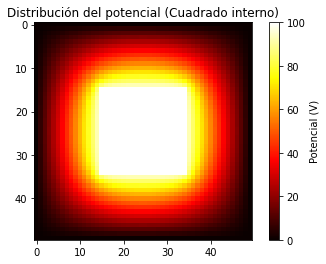

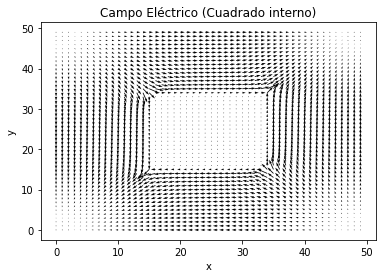

Máxima diferencia en esta iteración (círculo): 0.49873096446700504
Máxima diferencia en esta iteración (círculo): 0.18718274111675126
Máxima diferencia en esta iteración (círculo): 0.10921637055837563
Máxima diferencia en esta iteración (círculo): 0.09309671753126159
Máxima diferencia en esta iteración (círculo): 0.06990048044272834
Máxima diferencia en esta iteración (círculo): 0.057205710982899616
Máxima diferencia en esta iteración (círculo): 0.048186915177029
Máxima diferencia en esta iteración (círculo): 0.039495746042078506
Máxima diferencia en esta iteración (círculo): 0.035774955094650895
Máxima diferencia en esta iteración (círculo): 0.03190892720951782
Máxima diferencia en esta iteración (círculo): 0.02935619957314417
Máxima diferencia en esta iteración (círculo): 0.026376781619421752
Máxima diferencia en esta iteración (círculo): 0.024535024006383244
Máxima diferencia en esta iteración (círculo): 0.022425204557952938
Máxima diferencia en esta iteración (círculo): 0.020840475

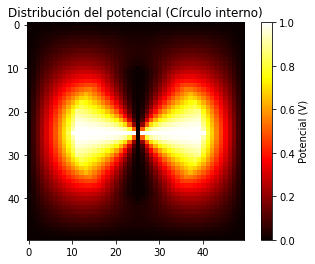

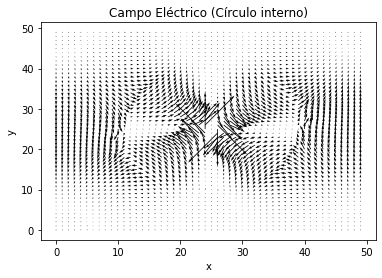

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos el tamaño de la cuadrícula
grid_size = 50  # Tamaño de la cuadrícula

# ---- CASO 1: CUADRADO INTERNO ----

# Inicializamos la cuadrícula con ceros
potential_square = np.zeros((grid_size, grid_size))

# Condiciones de frontera
potential_square[:, 0] = 0  # Borde izquierdo
potential_square[:, -1] = 0  # Borde derecho
potential_square[0, :] = 0  # Borde superior
potential_square[-1, :] = 0  # Borde inferior

# Definir un cuadrado interno con potencial φ=100
internal_square_size = 20  # Tamaño del cuadrado interno
start = (grid_size - internal_square_size) // 2
end = start + internal_square_size

potential_square[start:end, start:end] = 100  # Región interna a φ = 100

# Función de relajación para el cuadrado
def relaxation_step_square(potential, tolerance=1e-4):
    max_diff = tolerance + 1  # Iniciar con una diferencia mayor al criterio
    while max_diff > tolerance:
        new_potential = potential.copy()  # Crear una copia de los valores actuales
        max_diff = 0  # Inicializar la diferencia máxima

        # Actualizar cada punto interno de la cuadrícula
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                if not (start <= i < end and start <= j < end):  # Saltar la región de φ = 100
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential  # Actualizar la cuadrícula con los nuevos valores
        print(f"Máxima diferencia en esta iteración (cuadrado): {max_diff}")
    
    return potential

# Graficar el potencial para el cuadrado
def plot_potential_square(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Cuadrado interno)")
    plt.show()

# Ejecutar el método de relajación para el cuadrado y graficar
relaxed_potential_square = relaxation_step_square(potential_square)
plot_potential_square(relaxed_potential_square)

# Calcular el campo eléctrico para el cuadrado y graficar
Ex_square, Ey_square = np.gradient(-relaxed_potential_square)

def plot_electric_field_square(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Cuadrado interno)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_square(Ex_square, Ey_square)

# ---- CASO 2: CÍRCULO INTERNO ----

# Inicializamos la cuadrícula con ceros
potential_circle = np.zeros((grid_size, grid_size))

# Condiciones de frontera (cuadrado exterior a φ = 0)
potential_circle[:, 0] = 0  # Borde izquierdo
potential_circle[:, -1] = 0  # Borde derecho
potential_circle[0, :] = 0  # Borde superior
potential_circle[-1, :] = 0  # Borde inferior

# Definir un círculo interno con φ(θ) = sin²(θ)
radius = 15  # Radio del círculo interno
center = grid_size // 2  # Centro del círculo en la cuadrícula

# Aplicamos las condiciones de frontera en el círculo interno
for i in range(grid_size):
    for j in range(grid_size):
        dist = np.sqrt((i - center)**2 + (j - center)**2)
        if dist <= radius:
            theta = np.arctan2(j - center, i - center)
            potential_circle[i, j] = np.sin(theta)**2  # φ(θ) = sin²(θ)

# Función de relajación para el círculo
def relaxation_step_circle(potential, tolerance=1e-4):
    max_diff = tolerance + 1
    while max_diff > tolerance:
        new_potential = potential.copy()
        max_diff = 0
        
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                dist = np.sqrt((i - center)**2 + (j - center)**2)
                if dist > radius:  # Saltar la región del círculo
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential
        print(f"Máxima diferencia en esta iteración (círculo): {max_diff}")
    
    return potential

# Graficar el potencial para el círculo
def plot_potential_circle(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Círculo interno)")
    plt.show()

# Ejecutamos el método de relajación para el círculo y graficamos
relaxed_potential_circle = relaxation_step_circle(potential_circle)
plot_potential_circle(relaxed_potential_circle)

# Calcular el campo eléctrico para el círculo y graficarlo
Ex_circle, Ey_circle = np.gradient(-relaxed_potential_circle)

def plot_electric_field_circle(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Círculo interno)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_circle(Ex_circle, Ey_circle)


Máxima diferencia en esta iteración (cuadrado): 50.0
Máxima diferencia en esta iteración (cuadrado): 18.75
Máxima diferencia en esta iteración (cuadrado): 12.5
Máxima diferencia en esta iteración (cuadrado): 6.640625
Máxima diferencia en esta iteración (cuadrado): 5.859375
Máxima diferencia en esta iteración (cuadrado): 3.4912109375
Máxima diferencia en esta iteración (cuadrado): 3.4423828125
Máxima diferencia en esta iteración (cuadrado): 2.496337890625
Máxima diferencia en esta iteración (cuadrado): 2.28271484375
Máxima diferencia en esta iteración (cuadrado): 1.8671989440917969
Máxima diferencia en esta iteración (cuadrado): 1.6334056854248047
Máxima diferencia en esta iteración (cuadrado): 1.4495670795440674
Máxima diferencia en esta iteración (cuadrado): 1.2315034866333008
Máxima diferencia en esta iteración (cuadrado): 1.1591538786888123
Máxima diferencia en esta iteración (cuadrado): 1.0224446654319763
Máxima diferencia en esta iteración (cuadrado): 0.949053093791008
Máxima dife

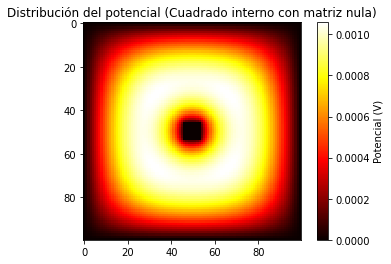

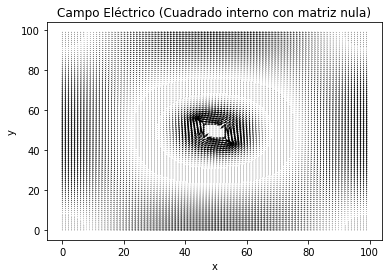

Máxima diferencia en esta iteración (círculo): 0.4969512195121951
Máxima diferencia en esta iteración (círculo): 0.18673780487804878
Máxima diferencia en esta iteración (círculo): 0.1089939024390244
Máxima diferencia en esta iteración (círculo): 0.0922446646341463
Máxima diferencia en esta iteración (círculo): 0.06521532012195125
Máxima diferencia en esta iteración (círculo): 0.05545207698170734
Máxima diferencia en esta iteración (círculo): 0.04342898485137198
Máxima diferencia en esta iteración (círculo): 0.03853268507050306
Máxima diferencia en esta iteración (círculo): 0.03394046318240279
Máxima diferencia en esta iteración (círculo): 0.030514460307795838
Máxima diferencia en esta iteración (círculo): 0.027259464380217785
Máxima diferencia en esta iteración (círculo): 0.024692499637603782
Máxima diferencia en esta iteración (círculo): 0.02236280074206798
Máxima diferencia en esta iteración (círculo): 0.020396841251995534
Máxima diferencia en esta iteración (círculo): 0.018699582003

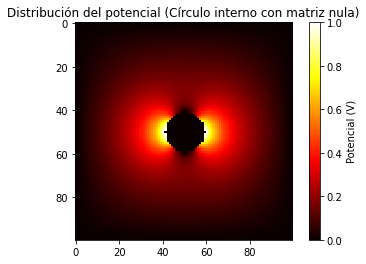

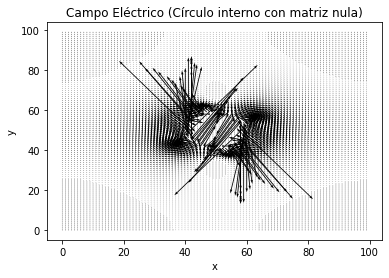

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos el tamaño de la cuadrícula
grid_size = 100  # Tamaño de la cuadrícula

# ---- CASO 1: CUADRADO INTERNO CON MATRIZ NULA ----

# Inicializamos la cuadrícula con ceros
potential_square = np.zeros((grid_size, grid_size))

# Condiciones de frontera
potential_square[:, 0] = 0  # Borde izquierdo
potential_square[:, -1] = 0  # Borde derecho
potential_square[0, :] = 0  # Borde superior
potential_square[-1, :] = 0  # Borde inferior

# Definir un cuadrado interno con potencial solo en la frontera
internal_square_size = 10  # Tamaño del cuadrado interno
start = (grid_size - internal_square_size) // 2
end = start + internal_square_size

# Establecer el potencial solo en la frontera del cuadrado
potential_square[start, start:end] = 100  # Lado superior
potential_square[end-1, start:end] = 100  # Lado inferior
potential_square[start:end, start] = 100  # Lado izquierdo
potential_square[start:end, end-1] = 100  # Lado derecho

# Función de relajación para el cuadrado con matriz nula en el centro
def relaxation_step_square(potential, tolerance=1e-6):
    max_diff = tolerance + 1
    while max_diff > tolerance:
        new_potential = potential.copy()
        max_diff = 0
        
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                if not (start < i < end-1 and start < j < end-1):  # Mantener matriz nula en el interior
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential
        print(f"Máxima diferencia en esta iteración (cuadrado): {max_diff}")
    
    return potential

# Graficar el potencial para el cuadrado
def plot_potential_square(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Cuadrado interno con matriz nula)")
    plt.show()

# Ejecutar el método de relajación para el cuadrado y graficar
relaxed_potential_square = relaxation_step_square(potential_square)
plot_potential_square(relaxed_potential_square)

# Calcular el campo eléctrico para el cuadrado y graficar
Ex_square, Ey_square = np.gradient(-relaxed_potential_square)

def plot_electric_field_square(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Cuadrado interno con matriz nula)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_square(Ex_square, Ey_square)

# ---- CASO 2: CÍRCULO INTERNO CON MATRIZ NULA ----

# Inicializamos la cuadrícula con ceros
potential_circle = np.zeros((grid_size, grid_size))

# Condiciones de frontera (cuadrado exterior a φ = 0)
potential_circle[:, 0] = 0  # Borde izquierdo
potential_circle[:, -1] = 0  # Borde derecho
potential_circle[0, :] = 0  # Borde superior
potential_circle[-1, :] = 0  # Borde inferior

# Definir un círculo interno con φ(θ) = sin²(θ) solo en la frontera
radius = 10  # Radio del círculo interno
center = grid_size // 2  # Centro del círculo en la cuadrícula

# Aplicamos las condiciones de frontera solo en el borde del círculo
for i in range(grid_size):
    for j in range(grid_size):
        dist = np.sqrt((i - center)**2 + (j - center)**2)
        if radius - 1 < dist <= radius:
            theta = np.arctan2(j - center, i - center)
            potential_circle[i, j] = np.sin(theta)**2  # φ(θ) = sin²(θ)

# Función de relajación para el círculo con matriz nula en el centro
def relaxation_step_circle(potential, tolerance=1e-6):
    max_diff = tolerance + 1
    while max_diff > tolerance:
        new_potential = potential.copy()
        max_diff = 0
        
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                dist = np.sqrt((i - center)**2 + (j - center)**2)
                if dist > radius:  # Saltar la región del círculo interno
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential
        print(f"Máxima diferencia en esta iteración (círculo): {max_diff}")
    
    return potential

# Graficar el potencial para el círculo
def plot_potential_circle(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Círculo interno con matriz nula)")
    plt.show()

# Ejecutamos el método de relajación para el círculo y graficamos
relaxed_potential_circle = relaxation_step_circle(potential_circle)
plot_potential_circle(relaxed_potential_circle)

# Calcular el campo eléctrico para el círculo y graficarlo
Ex_circle, Ey_circle = np.gradient(-relaxed_potential_circle)

def plot_electric_field_circle(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Círculo interno con matriz nula)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_circle(Ex_circle, Ey_circle)


Máxima diferencia en esta iteración (cuadrado): 50.0
Máxima diferencia en esta iteración (cuadrado): 18.75
Máxima diferencia en esta iteración (cuadrado): 12.5
Máxima diferencia en esta iteración (cuadrado): 6.640625
Máxima diferencia en esta iteración (cuadrado): 5.859375
Máxima diferencia en esta iteración (cuadrado): 3.4912109375
Máxima diferencia en esta iteración (cuadrado): 3.4423828125
Máxima diferencia en esta iteración (cuadrado): 2.496337890625
Máxima diferencia en esta iteración (cuadrado): 2.28271484375
Máxima diferencia en esta iteración (cuadrado): 1.8671989440917969
Máxima diferencia en esta iteración (cuadrado): 1.633453369140625
Máxima diferencia en esta iteración (cuadrado): 1.4496445655822754
Máxima diferencia en esta iteración (cuadrado): 1.2317657470703125
Máxima diferencia en esta iteración (cuadrado): 1.159508153796196
Máxima diferencia en esta iteración (cuadrado): 1.0226409882307053
Máxima diferencia en esta iteración (cuadrado): 0.9499439969658852
Máxima difer

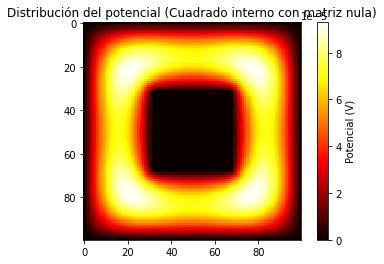

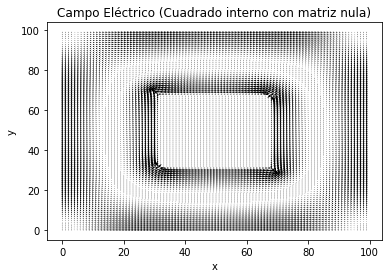

Máxima diferencia en esta iteración (círculo): 0.4997030878859857
Máxima diferencia en esta iteración (círculo): 0.19359730263450475
Máxima diferencia en esta iteración (círculo): 0.10933788598574823
Máxima diferencia en esta iteración (círculo): 0.09359344435517677
Máxima diferencia en esta iteración (círculo): 0.07094861736406258
Máxima diferencia en esta iteración (círculo): 0.057701835619830055
Máxima diferencia en esta iteración (círculo): 0.048840893327098456
Máxima diferencia en esta iteración (círculo): 0.039887701734498404
Máxima diferencia en esta iteración (círculo): 0.03612095841219298
Máxima diferencia en esta iteración (círculo): 0.03219318236870028
Máxima diferencia en esta iteración (círculo): 0.029678347158208385
Máxima diferencia en esta iteración (círculo): 0.026812229215272765
Máxima diferencia en esta iteración (círculo): 0.024842613470525188
Máxima diferencia en esta iteración (círculo): 0.022861401102402812
Máxima diferencia en esta iteración (círculo): 0.0211446

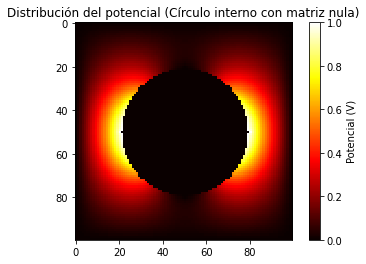

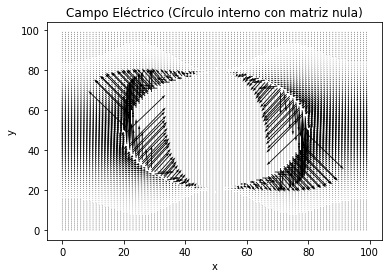

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos el tamaño de la cuadrícula
grid_size = 100  # Tamaño de la cuadrícula

# ---- CASO 1: CUADRADO INTERNO CON MATRIZ NULA ----

# Inicializamos la cuadrícula con ceros
potential_square = np.zeros((grid_size, grid_size))

# Condiciones de frontera
potential_square[:, 0] = 0  # Borde izquierdo
potential_square[:, -1] = 0  # Borde derecho
potential_square[0, :] = 0  # Borde superior
potential_square[-1, :] = 0  # Borde inferior

# Definir un cuadrado interno con potencial solo en la frontera
internal_square_size = 40  # Tamaño del cuadrado interno
start = (grid_size - internal_square_size) // 2
end = start + internal_square_size

# Establecer el potencial solo en la frontera del cuadrado
potential_square[start, start:end] = 100  # Lado superior
potential_square[end-1, start:end] = 100  # Lado inferior
potential_square[start:end, start] = 100  # Lado izquierdo
potential_square[start:end, end-1] = 100  # Lado derecho

# Función de relajación para el cuadrado con matriz nula en el centro
def relaxation_step_square(potential, tolerance=1e-6):
    max_diff = tolerance + 1
    while max_diff > tolerance:
        new_potential = potential.copy()
        max_diff = 0
        
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                if not (start < i < end-1 and start < j < end-1):  # Mantener matriz nula en el interior
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential
        print(f"Máxima diferencia en esta iteración (cuadrado): {max_diff}")
    
    return potential

# Graficar el potencial para el cuadrado
def plot_potential_square(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Cuadrado interno con matriz nula)")
    plt.show()

# Ejecutar el método de relajación para el cuadrado y graficar
relaxed_potential_square = relaxation_step_square(potential_square)
plot_potential_square(relaxed_potential_square)

# Calcular el campo eléctrico para el cuadrado y graficar
Ex_square, Ey_square = np.gradient(-relaxed_potential_square)

def plot_electric_field_square(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Cuadrado interno con matriz nula)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_square(Ex_square, Ey_square)

# ---- CASO 2: CÍRCULO INTERNO CON MATRIZ NULA ----

# Inicializamos la cuadrícula con ceros
potential_circle = np.zeros((grid_size, grid_size))

# Condiciones de frontera (cuadrado exterior a φ = 0)
potential_circle[:, 0] = 0  # Borde izquierdo
potential_circle[:, -1] = 0  # Borde derecho
potential_circle[0, :] = 0  # Borde superior
potential_circle[-1, :] = 0  # Borde inferior

# Definir un círculo interno con φ(θ) = sin²(θ) solo en la frontera
radius = 30  # Radio del círculo interno
center = grid_size // 2  # Centro del círculo en la cuadrícula

# Aplicamos las condiciones de frontera solo en el borde del círculo
for i in range(grid_size):
    for j in range(grid_size):
        dist = np.sqrt((i - center)**2 + (j - center)**2)
        if radius - 1 < dist <= radius:
            theta = np.arctan2(j - center, i - center)
            potential_circle[i, j] = np.sin(theta)**2  # φ(θ) = sin²(θ)

# Función de relajación para el círculo con matriz nula en el centro
def relaxation_step_circle(potential, tolerance=1e-6):
    max_diff = tolerance + 1
    while max_diff > tolerance:
        new_potential = potential.copy()
        max_diff = 0
        
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                dist = np.sqrt((i - center)**2 + (j - center)**2)
                if dist > radius:  # Saltar la región del círculo interno
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential
        print(f"Máxima diferencia en esta iteración (círculo): {max_diff}")
    
    return potential

# Graficar el potencial para el círculo
def plot_potential_circle(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Círculo interno con matriz nula)")
    plt.show()

# Ejecutamos el método de relajación para el círculo y graficamos
relaxed_potential_circle = relaxation_step_circle(potential_circle)
plot_potential_circle(relaxed_potential_circle)

# Calcular el campo eléctrico para el círculo y graficarlo
Ex_circle, Ey_circle = np.gradient(-relaxed_potential_circle)

def plot_electric_field_circle(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Círculo interno con matriz nula)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_circle(Ex_circle, Ey_circle)


Máxima diferencia en esta iteración (cuadrado): 25.0
Máxima diferencia en esta iteración (cuadrado): 12.5
Máxima diferencia en esta iteración (cuadrado): 7.8125
Máxima diferencia en esta iteración (cuadrado): 6.25
Máxima diferencia en esta iteración (cuadrado): 4.6875
Máxima diferencia en esta iteración (cuadrado): 4.0283203125
Máxima diferencia en esta iteración (cuadrado): 3.4912109375
Máxima diferencia en esta iteración (cuadrado): 3.0548095703125
Máxima diferencia en esta iteración (cuadrado): 2.69775390625
Máxima diferencia en esta iteración (cuadrado): 2.4026870727539062
Máxima diferencia en esta iteración (cuadrado): 2.1562576293945312
Máxima diferencia en esta iteración (cuadrado): 1.9483327865600586
Máxima diferencia en esta iteración (cuadrado): 1.826561987400055
Máxima diferencia en esta iteración (cuadrado): 1.7142333090305328
Máxima diferencia en esta iteración (cuadrado): 1.6110618598759174
Máxima diferencia en esta iteración (cuadrado): 1.5164853539317846
Máxima diferenc

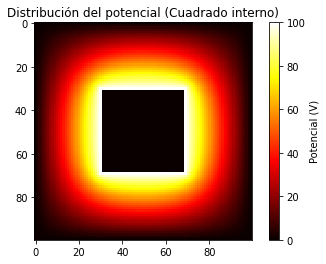

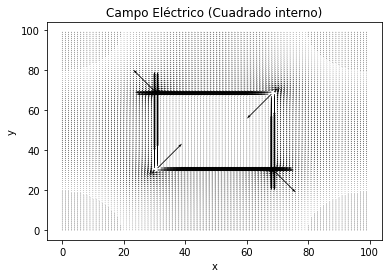

In [15]:
import numpy as np 
import matplotlib.pyplot as plt

# Definimos el tamaño de la cuadrícula
grid_size = 100  # Tamaño de la cuadrícula

# ---- CASO 1: CUADRADO INTERNO ----

# Inicializamos la cuadrícula con ceros
potential_square = np.zeros((grid_size, grid_size))

# Condiciones de frontera externas (cuadrícula)
potential_square[:, 0] = 0  # Borde izquierdo
potential_square[:, -1] = 0  # Borde derecho
potential_square[0, :] = 0  # Borde superior
potential_square[-1, :] = 0  # Borde inferior

# Definir un cuadrado interno con potencial solo en los bordes
internal_square_size = 40  # Tamaño del cuadrado interno
start = (grid_size - internal_square_size) // 2
end = start + internal_square_size

# Bordes del cuadrado con potencial φ = 100
potential_square[start, start:end] = 100  # Lado superior
potential_square[end-1, start:end] = 100  # Lado inferior
potential_square[start:end, start] = 100  # Lado izquierdo
potential_square[start:end, end-1] = 100  # Lado derecho

# El interior del cuadrado será 0
potential_square[start+1:end-1, start+1:end-1] = 0

# Función de relajación para el cuadrado con interior nulo
def relaxation_step_square(potential, tolerance=1e-4):
    max_diff = tolerance + 1  # Iniciar con una diferencia mayor al criterio
    while max_diff > tolerance:
        new_potential = potential.copy()  # Crear una copia de los valores actuales
        max_diff = 0  # Inicializar la diferencia máxima

        # Actualizar cada punto interno de la cuadrícula
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                # Saltar la región del cuadrado interno (mantener 0 en el interior)
                if not (start <= i < end and start <= j < end):
                    new_value = 0.25 * (potential[i+1, j] + potential[i-1, j] +
                                        potential[i, j+1] + potential[i, j-1])
                    max_diff = max(max_diff, abs(new_value - potential[i, j]))
                    new_potential[i, j] = new_value

        potential = new_potential  # Actualizar la cuadrícula con los nuevos valores
        print(f"Máxima diferencia en esta iteración (cuadrado): {max_diff}")
    
    return potential

# Graficar el potencial para el cuadrado
def plot_potential_square(potential):
    plt.imshow(potential, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Potencial (V)")
    plt.title("Distribución del potencial (Cuadrado interno)")
    plt.show()

# Ejecutar el método de relajación para el cuadrado y graficar
relaxed_potential_square = relaxation_step_square(potential_square)
plot_potential_square(relaxed_potential_square)

# Calcular el campo eléctrico para el cuadrado y graficar
Ex_square, Ey_square = np.gradient(-relaxed_potential_square)

def plot_electric_field_square(Ex, Ey):
    plt.quiver(Ex, Ey)
    plt.title("Campo Eléctrico (Cuadrado interno)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_electric_field_square(Ex_square, Ey_square)
